libraries


In [1]:
import os
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


print("TensorFlow version:", tf.__version__)
print("All imports successful!")

TensorFlow version: 2.18.0
All imports successful!


In [2]:
# Path setup
TRAIN_DIR = r"C:\Users\yasha\OneDrive\Desktop\yoga recognition\yoga recognition\TRAIN\TRAIN"
IMG_SIZE  = (224, 224)
BATCH     = 32

# Classes check
classes = sorted(os.listdir(TRAIN_DIR))
print("Classes found:", classes)
print("Total classes:", len(classes))
for cls in classes:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"  {cls:<12} {count} images")

Classes found: ['downdog', 'goddess', 'plank', 'tree', 'warrior']
Total classes: 5
  downdog      188 images
  goddess      70 images
  plank        96 images
  tree         129 images
  warrior      332 images


In [3]:
# Data generators with augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("\nTraining images  :", train_data.samples)
print("Validation images:", val_data.samples)
print("Classes          :", train_data.class_indices)

Found 946 images belonging to 5 classes.
Found 234 images belonging to 5 classes.

Training images  : 946
Validation images: 234
Classes          : {'downdog': 0, 'goddess': 1, 'plank': 2, 'tree': 3, 'warrior': 4}


In [4]:
from sklearn.utils.class_weight import compute_class_weight

labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',                           # Class weights - imbalance fix
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:")
for i, cls in enumerate(classes):
    print(f"  {cls:<12} weight = {class_weight_dict[i]:.2f}")

Class weights:
  downdog      weight = 1.25
  goddess      weight = 1.12
  plank        weight = 0.74
  tree         weight = 1.82
  warrior      weight = 0.71


In [5]:

# Model - ResNet50 Transfer Learning
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model ready!")
print(f"Total parameters: {model.count_params():,}")

Model ready!
Total parameters: 24,113,541


In [6]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [7]:
from tensorflow.keras.layers import Input, Concatenate, Dense, Dropout, GlobalAveragePooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

print("Imports ready!")

Imports ready!


In [8]:
import numpy as np
TRAIN_DIR = r"C:\Users\yasha\OneDrive\Desktop\yoga recognition\yoga recognition\TRAIN\TRAIN"
CLASSES = ['downdog', 'goddess', 'plank', 'tree', 'warrior']
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
from pathlib import Path
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

X_images = []
y_labels = []

print("Loading Images")
for label, cls in enumerate(CLASSES):
    cls_path = Path(TRAIN_DIR) / cls
    files = [f for f in cls_path.iterdir() if f.suffix.lower() in IMG_EXTS]
    for fp in files:
        try:
            img = load_img(str(fp), target_size=(224, 224))
            img = img_to_array(img) / 255.0
            X_images.append(img)
            y_labels.append(label)
        except:
            pass
    print(f"  {cls:<12} {len(files)} images loaded")

X_images = np.array(X_images)
y_labels = np.array(y_labels)
y_cat = to_categorical(y_labels, num_classes=5)

print(f"\nTotal images: {X_images.shape}")

Loading Images


c:\Users\yasha\OneDrive\Desktop\yoga recognition\venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  downdog      188 images loaded
  goddess      69 images loaded
  plank        95 images loaded
  tree         129 images loaded
  warrior      332 images loaded

Total images: (813, 224, 224, 3)


In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X_images, y_cat,
    test_size=0.2, random_state=42, stratify=y_labels
)
print(f"Train: {X_train.shape[0]}")
print(f"Val  : {X_val.shape[0]}")

Train: 650
Val  : 163


In [10]:
# Branch 1 - ResNet50
import tensorflow as tf
img_input = Input(shape=(224, 224, 3), name='image_input')
base = ResNet50(weights='imagenet', include_top=False, input_tensor=img_input)
base.trainable = False
x1 = GlobalAveragePooling2D()(base.output)
x1 = Dense(256, activation='relu')(x1)
x1 = Dropout(0.3)(x1)

# Branch 2 - MobileNetV2
mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mobile.trainable = False
x2 = mobile(img_input)
x2 = GlobalAveragePooling2D()(x2)
x2 = Dense(256, activation='relu')(x2)
x2 = Dropout(0.3)(x2)

# Join dono branches
combined = Concatenate()([x1, x2])
x = Dense(512, activation='relu')(combined)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

combined_model = Model(inputs=img_input, outputs=output)
combined_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Combined model ready!")
print(f"Total parameters: {combined_model.count_params():,}")

Combined model ready!
Total parameters: 27,093,445


In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels_train = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_combined.keras', save_best_only=True,
        monitor='val_accuracy', verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=8, monitor='val_accuracy',
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, verbose=1
    )
]

history = combined_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f"\nBest Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Class weights: {0: np.float64(0.8666666666666667), 1: np.float64(2.3636363636363638), 2: np.float64(1.7105263157894737), 3: np.float64(1.2621359223300972), 4: np.float64(0.48872180451127817)}
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2364 - loss: 1.8130
Epoch 1: val_accuracy improved from None to 0.60736, saving model to best_combined.keras

Epoch 1: finished saving model to best_combined.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - accuracy: 0.2769 - loss: 1.6864 - val_accuracy: 0.6074 - val_loss: 1.1151 - learning_rate: 0.0010
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5053 - loss: 1.0850
Epoch 2: val_accuracy improved from 0.60736 to 0.83436, saving model to best_combined.keras

Epoch 2: finished saving model to best_combined.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.5862 - loss: 0.9601 - val_accuracy: 0.8344 - val_loss: 0.5252 - learning_rate: 0.0010
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7343 - los

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9141 - loss: 0.3394

Final Accuracy: 91.41%
6/6 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step

               precision    recall  f1-score   support

     downdog       0.97      0.84      0.90        38
     goddess       0.92      0.86      0.89        14
       plank       1.00      0.84      0.91        19
        tree       0.83      0.92      0.87        26
     warrior       0.90      0.98      0.94        66

    accuracy                           0.91       163
   macro avg       0.92      0.89      0.90       163
weighted avg       0.92      0.91      0.91       163



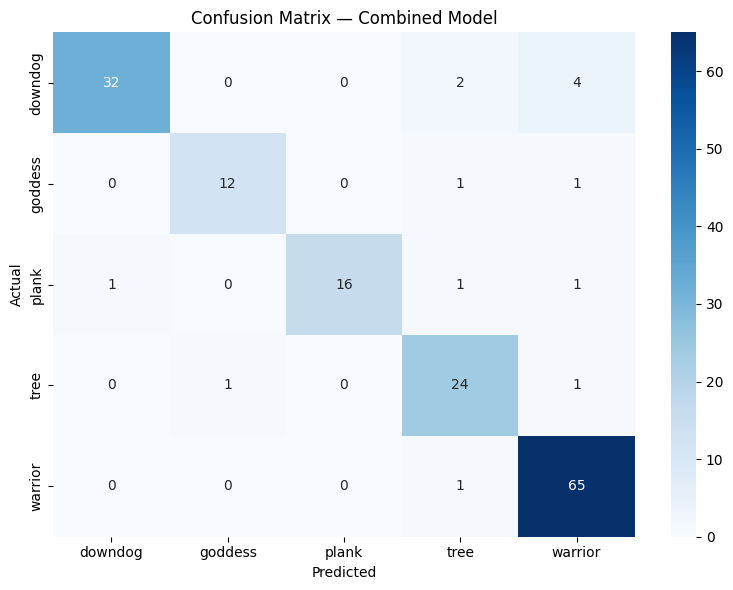

In [13]:
loss, accuracy = combined_model.evaluate(X_val, y_val, verbose=1)
print(f"\nFinal Accuracy: {accuracy*100:.2f}%")

y_pred = combined_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

print("\n", classification_report(y_true_classes, y_pred_classes, target_names=CLASSES))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Combined Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [14]:
import tensorflow as tf
combined_model = tf.keras.models.load_model('best_combined.keras')
print("Model loaded!")

Model loaded!


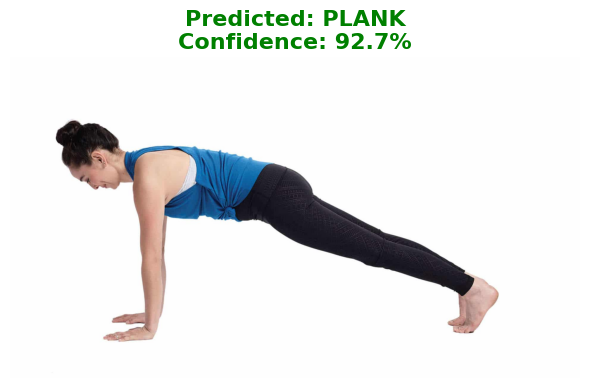


Predicted Pose : plank
Confidence     : 92.7%

All class probabilities:
  downdog        1.1%  
  goddess        0.0%  
  plank         92.7%  ██████████████████
  tree           0.6%  
  warrior        5.5%  █


In [15]:
from PIL import Image
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt

CLASSES = ['downdog', 'goddess', 'plank', 'tree', 'warrior']

# ⬇ APNA IMAGE PATH YAHAN DAALO
image_path = r"C:\Users\yasha\OneDrive\Desktop\yoga recognition\yoga recognition\TRAIN\TRAIN\plank\00000000.jpg"
# Load and preprocess
img = Image.open(image_path).convert('RGB')
img_resized = img.resize((224, 224))
img_array = img_to_array(img_resized) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = combined_model.predict(img_array, verbose=0)
class_idx = np.argmax(pred)
confidence = pred[0][class_idx] * 100

# Show result
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {CLASSES[class_idx].upper()}\nConfidence: {confidence:.1f}%",
          fontsize=16, fontweight='bold', color='green')
plt.tight_layout()
plt.show()

print(f"\nPredicted Pose : {CLASSES[class_idx]}")
print(f"Confidence     : {confidence:.1f}%")
print("\nAll class probabilities:")
for i, cls in enumerate(CLASSES):
    bar = '█' * int(pred[0][i] * 20)
    print(f"  {cls:<12} {pred[0][i]*100:5.1f}%  {bar}")

In [16]:
import cv2
import numpy as np
from PIL import Image, ImageFile
from pathlib import Path

ImageFile.LOAD_TRUNCATED_IMAGES = True

# MoveNet keypoints indices
KEYPOINTS = {
    'nose': 0, 'left_eye': 1, 'right_eye': 2,
    'left_ear': 3, 'right_ear': 4,
    'left_shoulder': 5, 'right_shoulder': 6,
    'left_elbow': 7, 'right_elbow': 8,
    'left_wrist': 9, 'right_wrist': 10,
    'left_hip': 11, 'right_hip': 12,
    'left_knee': 13, 'right_knee': 14,
    'left_ankle': 15, 'right_ankle': 16
}

def calculate_angle(a, b, c):
    """3 points ke beech angle calculate karo"""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-7)
    angle = np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))
    return angle

def extract_angles_from_keypoints(kps):
    """17 keypoints se important angles nikalo"""
    def get(name):
        idx = KEYPOINTS[name]
        return [kps[idx][1], kps[idx][0]]  # x, y

    angles = []
    try:
        # Left elbow angle
        angles.append(calculate_angle(get('left_shoulder'), get('left_elbow'), get('left_wrist')))
        # Right elbow angle
        angles.append(calculate_angle(get('right_shoulder'), get('right_elbow'), get('right_wrist')))
        # Left shoulder angle
        angles.append(calculate_angle(get('left_elbow'), get('left_shoulder'), get('left_hip')))
        # Right shoulder angle
        angles.append(calculate_angle(get('right_elbow'), get('right_shoulder'), get('right_hip')))
        # Left hip angle
        angles.append(calculate_angle(get('left_shoulder'), get('left_hip'), get('left_knee')))
        # Right hip angle
        angles.append(calculate_angle(get('right_shoulder'), get('right_hip'), get('right_knee')))
        # Left knee angle
        angles.append(calculate_angle(get('left_hip'), get('left_knee'), get('left_ankle')))
        # Right knee angle
        angles.append(calculate_angle(get('right_hip'), get('right_knee'), get('right_ankle')))
        # Torso angle
        angles.append(calculate_angle(get('left_shoulder'), get('left_hip'), get('right_hip')))
        angles.append(calculate_angle(get('right_shoulder'), get('right_hip'), get('left_hip')))
    except:
        angles = [0.0] * 10

    return np.array(angles, dtype=np.float32)

print("Angle extractor ready!")
print(f"Total angle features: 10")

Angle extractor ready!
Total angle features: 10


In [17]:
import tensorflow as tf
import numpy as np
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

interpreter = tf.lite.Interpreter(model_path='movenet.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model loaded!")

def get_keypoints(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((257, 257))
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    
    # Heatmaps se keypoints nikalo
    heatmaps = interpreter.get_tensor(output_details[0]['index'])[0]  # (9,9,17)
    offsets  = interpreter.get_tensor(output_details[1]['index'])[0]  # (9,9,34)
    
    height, width = 257, 257
    num_keypoints = 17
    keypoints = np.zeros((num_keypoints, 3))  # y, x, confidence
    
    for kp_idx in range(num_keypoints):
        heatmap = heatmaps[:, :, kp_idx]
        conf = np.max(heatmap)
        
        # Peak position
        idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        y_cell, x_cell = idx
        
        # Offset se refine karo
        y_offset = offsets[y_cell, x_cell, kp_idx]
        x_offset = offsets[y_cell, x_cell, kp_idx + num_keypoints]
        
        # Normalize to 0-1
        y = (y_cell / 8.0 * 257 + y_offset) / height
        x = (x_cell / 8.0 * 257 + x_offset) / width
        
        keypoints[kp_idx] = [
            np.clip(y, 0, 1),
            np.clip(x, 0, 1),
            float(1 / (1 + np.exp(-conf)))  # sigmoid
        ]
    
    return keypoints

print("Keypoint extractor ready!")

# Test karo
from pathlib import Path
test_img = str(list((Path(TRAIN_DIR) / 'goddess').iterdir())[0])
kps = get_keypoints(test_img)
print(f"Keypoints shape: {kps.shape}")
print(f"Sample - nose: y={kps[0][0]:.3f}, x={kps[0][1]:.3f}, conf={kps[0][2]:.3f}")
print(f"Sample - shoulder: y={kps[5][0]:.3f}, x={kps[5][1]:.3f}, conf={kps[5][2]:.3f}")

Model loaded!
Keypoint extractor ready!
Keypoints shape: (17, 3)
Sample - nose: y=0.366, x=0.000, conf=0.001
Sample - shoulder: y=0.308, x=0.032, conf=0.001


In [18]:
from pathlib import Path

CLASSES = ['downdog', 'goddess', 'plank', 'tree', 'warrior']
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

X_angles = []
y_angle_labels = []

print("Angles extracting..")
for label, cls in enumerate(CLASSES):
    cls_path = Path(TRAIN_DIR) / cls
    files = [f for f in cls_path.iterdir() if f.suffix.lower() in IMG_EXTS]
    for fp in files:
        try:
            kps = get_keypoints(str(fp))
            angles = extract_angles_from_keypoints(kps)
            X_angles.append(angles)
            y_angle_labels.append(label)
        except:
            X_angles.append(np.zeros(10))
            y_angle_labels.append(label)
    print(f"  {cls:<12} done — {len(files)} images")

X_angles = np.array(X_angles)
y_angle_labels = np.array(y_angle_labels)
print(f"\nAngles shape: {X_angles.shape}")

Angles extracting..


c:\Users\yasha\OneDrive\Desktop\yoga recognition\venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  downdog      done — 188 images
  goddess      done — 69 images
  plank        done — 95 images
  tree         done — 129 images
  warrior      done — 332 images

Angles shape: (813, 10)


In [19]:
from tensorflow.keras.layers import Input, Concatenate, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Images load karo
from tensorflow.keras.preprocessing.image import load_img, img_to_array

CLASSES = ['downdog', 'goddess', 'plank', 'tree', 'warrior']
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

X_images = []
image_labels = []

print("Images loading ....")
for label, cls in enumerate(CLASSES):
    cls_path = Path(TRAIN_DIR) / cls
    files = [f for f in cls_path.iterdir() if f.suffix.lower() in IMG_EXTS]
    for fp in files:
        try:
            img = load_img(str(fp), target_size=(224, 224))
            img = img_to_array(img) / 255.0
            X_images.append(img)
            image_labels.append(label)
        except:
            pass
    print(f"  {cls:<12} done")

X_images = np.array(X_images)
image_labels = np.array(image_labels)

# Match karo angles aur images
min_len = min(len(X_images), len(X_angles))
X_images = X_images[:min_len]
X_angles_final = X_angles[:min_len]
y_final = image_labels[:min_len]

y_cat = to_categorical(y_final, num_classes=5)

# Train/val split
X_img_train, X_img_val, X_ang_train, X_ang_val, y_train, y_val = train_test_split(
    X_images, X_angles_final, y_cat,
    test_size=0.2, random_state=42, stratify=y_final
)

print(f"\nTrain: {X_img_train.shape[0]}")
print(f"Val  : {X_img_val.shape[0]}")
print(f"Angle features: {X_ang_train.shape[1]}")

Images loading ....
  downdog      done
  goddess      done
  plank        done
  tree         done
  warrior      done

Train: 650
Val  : 163
Angle features: 10


In [20]:
# Branch 1 - ResNet50
img_input = Input(shape=(224, 224, 3), name='image_input')
base_resnet = ResNet50(weights='imagenet', include_top=False, input_tensor=img_input)
base_resnet.trainable = False
x1 = GlobalAveragePooling2D()(base_resnet.output)
x1 = Dense(256, activation='relu')(x1)
x1 = Dropout(0.3)(x1)

# Branch 2 - MobileNetV2
mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mobile.trainable = False
x2 = mobile(img_input)
x2 = GlobalAveragePooling2D()(x2)
x2 = Dense(256, activation='relu')(x2)
x2 = Dropout(0.3)(x2)

# Branch 3 - Angle features
angle_input = Input(shape=(10,), name='angle_input')
x3 = Dense(64, activation='relu')(angle_input)
x3 = Dropout(0.2)(x3)
x3 = Dense(32, activation='relu')(x3)

# Teen branches join karo
combined = Concatenate()([x1, x2, x3])
x = Dense(512, activation='relu')(combined)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

new_model = Model(inputs=[img_input, angle_input], outputs=output)
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("3-Branch model ready!")
print(f"Total parameters: {new_model.count_params():,}")

3-Branch model ready!
Total parameters: 27,112,613


In [21]:
from sklearn.utils.class_weight import compute_class_weight

labels_train = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", {CLASSES[k]: round(v, 2) for k, v in class_weight_dict.items()})

Class weights: {'downdog': np.float64(0.87), 'goddess': np.float64(2.36), 'plank': np.float64(1.71), 'tree': np.float64(1.26), 'warrior': np.float64(0.49)}


In [22]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_angle_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        monitor='val_accuracy',
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = new_model.fit(
    [X_img_train, X_ang_train], y_train,
    validation_data=([X_img_val, X_ang_val], y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f"\nBest Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2431 - loss: 7.5922
Epoch 1: val_accuracy improved from None to 0.19632, saving model to best_angle_model.keras

Epoch 1: finished saving model to best_angle_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 157s 5s/step - accuracy: 0.2185 - loss: 6.6176 - val_accuracy: 0.1963 - val_loss: 2.5004 - learning_rate: 0.0010
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2315 - loss: 3.3918
Epoch 2: val_accuracy improved from 0.19632 to 0.27607, saving model to best_angle_model.keras

Epoch 2: finished saving model to best_angle_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.2292 - loss: 3.0572 - val_accuracy: 0.2761 - val_loss: 1.6220 - learning_rate: 0.0010
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2818 - loss: 2.1609
Epoch 3: val_accuracy improved from 0.27607 to 0.46626, saving model to best_angle_model.keras

Epoch 3: finished saving model to best_angle_model.keras
21/21 ━━━━━━━━━━

6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9141 - loss: 0.2974
Final Accuracy: 91.41%
5/6 ━━━━━━━━━━━━━━━━━━━━ 2s 3s/stepWARNING:tensorflow:5 out of the last 13 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001CDC78CC0E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step
              precision    recall  f1-score   support

     downdog       0.97      0.87      0.92        3

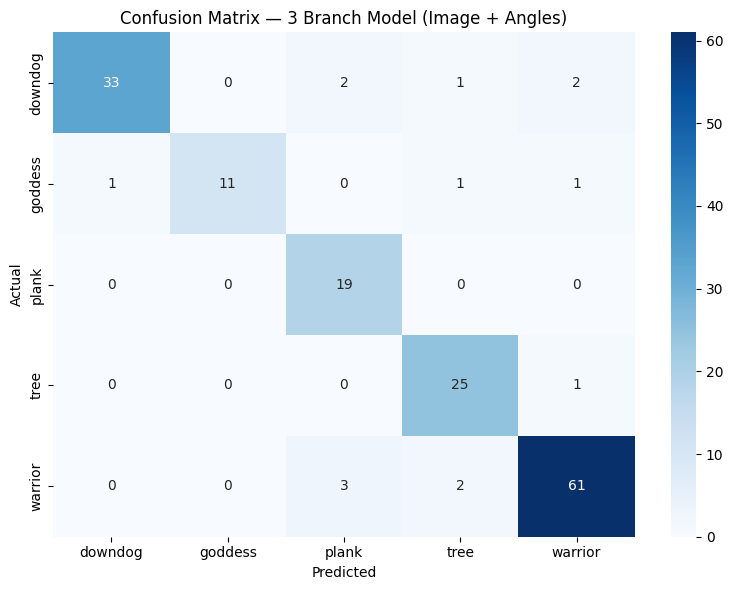

In [23]:
loss, accuracy = new_model.evaluate(
    [X_img_val, X_ang_val], y_val, verbose=1
)
print(f"Final Accuracy: {accuracy*100:.2f}%")

y_pred = new_model.predict([X_img_val, X_ang_val])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_true_classes, y_pred_classes, target_names=CLASSES))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — 3 Branch Model (Image + Angles)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [24]:
# Test - angles
test_img = str(list((Path(TRAIN_DIR) / 'goddess').iterdir())[0])
kps = get_keypoints(test_img)
angles = extract_angles_from_keypoints(kps)
print("Angles:", angles)

Angles: [ 39.983242  22.760443 105.642006 153.17879  102.1017   164.85555
  21.451452 103.837944 171.63246   60.276993]


In [25]:
from pathlib import Path

CLASSES = ['downdog', 'goddess', 'plank', 'tree', 'warrior']
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

X_angles_new = []
y_angle_labels_new = []

print("Angles extracting...")
for label, cls in enumerate(CLASSES):
    cls_path = Path(TRAIN_DIR) / cls
    files = [f for f in cls_path.iterdir() if f.suffix.lower() in IMG_EXTS]
    for fp in files:
        try:
            kps = get_keypoints(str(fp))
            angles = extract_angles_from_keypoints(kps)
            X_angles_new.append(angles)
            y_angle_labels_new.append(label)
        except:
            X_angles_new.append(np.zeros(10))
            y_angle_labels_new.append(label)
    print(f"  {cls:<12} done — {len(files)} images")

X_angles_new = np.array(X_angles_new)
y_angle_labels_new = np.array(y_angle_labels_new)
print(f"\nAngles shape: {X_angles_new.shape}")

Angles extracting...


c:\Users\yasha\OneDrive\Desktop\yoga recognition\venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  downdog      done — 188 images
  goddess      done — 69 images
  plank        done — 95 images
  tree         done — 129 images
  warrior      done — 332 images

Angles shape: (813, 10)


In [26]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_images_new = []
image_labels_new = []

print("Images loading....")
for label, cls in enumerate(CLASSES):
    cls_path = Path(TRAIN_DIR) / cls
    files = [f for f in cls_path.iterdir() if f.suffix.lower() in IMG_EXTS]
    for fp in files:
        try:
            img = load_img(str(fp), target_size=(224, 224))
            img = img_to_array(img) / 255.0
            X_images_new.append(img)
            image_labels_new.append(label)
        except:
            pass
    print(f"  {cls:<12} done")

X_images_new = np.array(X_images_new)
image_labels_new = np.array(image_labels_new)

min_len = min(len(X_images_new), len(X_angles_new))
X_images_new = X_images_new[:min_len]
X_ang_new = X_angles_new[:min_len]
y_new = image_labels_new[:min_len]
y_cat_new = to_categorical(y_new, num_classes=5)

X_img_train, X_img_val, X_ang_train, X_ang_val, y_train, y_val = train_test_split(
    X_images_new, X_ang_new, y_cat_new,
    test_size=0.2, random_state=42, stratify=y_new
)

print(f"\nTrain: {X_img_train.shape[0]}")
print(f"Val  : {X_img_val.shape[0]}")

Images loading....
  downdog      done
  goddess      done
  plank        done
  tree         done
  warrior      done

Train: 650
Val  : 163


In [27]:
from tensorflow.keras.layers import Input, Concatenate, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50, MobileNetV2
from sklearn.utils.class_weight import compute_class_weight

# Branch 1 - ResNet50
img_input = Input(shape=(224, 224, 3), name='image_input')
base1 = ResNet50(weights='imagenet', include_top=False, input_tensor=img_input)
base1.trainable = False
x1 = GlobalAveragePooling2D()(base1.output)
x1 = Dense(256, activation='relu')(x1)
x1 = Dropout(0.3)(x1)

# Branch 2 - MobileNetV2
base2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base2.trainable = False
x2 = base2(img_input)
x2 = GlobalAveragePooling2D()(x2)
x2 = Dense(256, activation='relu')(x2)
x2 = Dropout(0.3)(x2)

# Branch 3 - Angles
angle_input = Input(shape=(10,), name='angle_input')
x3 = Dense(64, activation='relu')(angle_input)
x3 = Dropout(0.2)(x3)
x3 = Dense(32, activation='relu')(x3)

# Join
combined = Concatenate()([x1, x2, x3])
x = Dense(512, activation='relu')(combined)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

new_model = Model(inputs=[img_input, angle_input], outputs=output)
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model ready!")
print(f"Parameters: {new_model.count_params():,}")

Model ready!
Parameters: 27,112,613


In [28]:
# Class weights
labels_train = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Training
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_angle_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        monitor='val_accuracy',
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = new_model.fit(
    [X_img_train, X_ang_train], y_train,
    validation_data=([X_img_val, X_ang_val], y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f"\nBest Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Class weights: {0: np.float64(0.8666666666666667), 1: np.float64(2.3636363636363638), 2: np.float64(1.7105263157894737), 3: np.float64(1.2621359223300972), 4: np.float64(0.48872180451127817)}
Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2149 - loss: 9.6798
Epoch 1: val_accuracy improved from None to 0.27607, saving model to best_angle_model.keras

Epoch 1: finished saving model to best_angle_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 287s 13s/step - accuracy: 0.2154 - loss: 7.1492 - val_accuracy: 0.2761 - val_loss: 1.8507 - learning_rate: 0.0010
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.2885 - loss: 2.9273 
Epoch 2: val_accuracy improved from 0.27607 to 0.31288, saving model to best_angle_model.keras

Epoch 2: finished saving model to best_angle_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 360s 17s/step - accuracy: 0.2815 - loss: 2.6215 - val_accuracy: 0.3129 - val_loss: 1.5941 - learning_rate: 0.0010
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - acc